<a href="https://colab.research.google.com/github/HeshanNavindu-7/oil-spill-detection/blob/main/best_edge_unet_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tensorflow opencv-python-headless seaborn scikit-learn matplotlib pandas

import os
import cv2
import json
import shutil
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

EXPERIMENT_ID = "E02_BEST_EDGE_UNET_MOBILENETV2_192_FOCAL_DICE"

# Updated paths
PROJECT_DIR = Path("/content/drive/MyDrive/Oil Spill/Best Detection Model")
RAW_DATASET_DIR = Path("/content/drive/MyDrive/Oil spill Research /Lados Dataset")

# If the above raw path shows False, try this instead:
# RAW_DATASET_DIR = Path("/content/drive/MyDrive/Oil spill Research/Lados Dataset")

SPILL_IDS = {2, 3, 5}

IMG_SIZE = 192
BATCH_SIZE = 8
INITIAL_LR = 1e-4
FINE_TUNE_LR = 1e-5
EPOCHS_STAGE_1 = 30
EPOCHS_STAGE_2 = 20
MOBILENET_ALPHA = 0.75
AUTOTUNE = tf.data.AUTOTUNE

MODEL_DIR = PROJECT_DIR / "models"
PLOT_DIR = PROJECT_DIR / "plots"
RESULT_DIR = PROJECT_DIR / "results"
LOG_DIR = PROJECT_DIR / "logs"
TFLITE_DIR = PROJECT_DIR / "tflite"
PROCESSED_DIR = PROJECT_DIR / "processed"

for folder in [PROJECT_DIR, MODEL_DIR, PLOT_DIR, RESULT_DIR, LOG_DIR, TFLITE_DIR, PROCESSED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

for split in ["train", "valid", "test"]:
    (PROCESSED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (PROCESSED_DIR / split / "masks").mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_edge_unet_model.keras"

print("TensorFlow:", tf.__version__)
print("Experiment:", EXPERIMENT_ID)
print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_DIR exists:", PROJECT_DIR.exists())
print("RAW_DATASET_DIR:", RAW_DATASET_DIR)
print("RAW_DATASET_DIR exists:", RAW_DATASET_DIR.exists())
print("Best model path:", BEST_MODEL_PATH)

Mounted at /content/drive
TensorFlow: 2.20.0
Experiment: E02_BEST_EDGE_UNET_MOBILENETV2_192_FOCAL_DICE
PROJECT_DIR: /content/drive/MyDrive/Oil Spill/Best Detection Model
PROJECT_DIR exists: True
RAW_DATASET_DIR: /content/drive/MyDrive/Oil spill Research /Lados Dataset
RAW_DATASET_DIR exists: True
Best model path: /content/drive/MyDrive/Oil Spill/Best Detection Model/models/best_edge_unet_model.keras


In [3]:
def get_image_mask_paths(project_path: Path, split_name: str):
    img_dir = project_path / "processed" / split_name / "images"
    mask_dir = project_path / "processed" / split_name / "masks"

    image_map = {
        Path(f).stem: str(img_dir / f)
        for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    mask_map = {
        Path(f).stem: str(mask_dir / f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    }

    missing_masks = sorted(set(image_map) - set(mask_map))
    missing_images = sorted(set(mask_map) - set(image_map))

    if missing_masks or missing_images:
        print(f"{split_name}: Images without masks:", len(missing_masks))
        print(f"{split_name}: Masks without images:", len(missing_images))

    paired_keys = sorted(set(image_map.keys()) & set(mask_map.keys()))

    image_paths = [image_map[k] for k in paired_keys]
    mask_paths = [mask_map[k] for k in paired_keys]

    return image_paths, mask_paths


def convert_split_to_binary(raw_dataset_path: Path, project_path: Path, split_name: str):
    src_path = raw_dataset_path / split_name
    dst_img_path = project_path / "processed" / split_name / "images"
    dst_mask_path = project_path / "processed" / split_name / "masks"

    if not src_path.exists():
        raise FileNotFoundError(f"Missing split folder: {src_path}")

    files = sorted(os.listdir(src_path))

    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png")) and "_mask" not in f.lower()
    ]

    total_images = 0
    total_masks = 0
    empty_masks = 0
    total_oil_pixels = 0
    total_pixels = 0

    for img_file in image_files:
        base = Path(img_file).stem
        mask_file = f"{base}_mask.png"

        img_src = src_path / img_file
        mask_src = src_path / mask_file

        if not mask_src.exists():
            continue

        img = cv2.imread(str(img_src))
        mask = cv2.imread(str(mask_src), cv2.IMREAD_UNCHANGED)

        if img is None or mask is None:
            continue

        if mask.ndim == 3:
            mask = mask[:, :, 0]

        binary_mask = np.isin(mask, list(SPILL_IDS)).astype(np.uint8)

        if binary_mask.sum() == 0:
            empty_masks += 1

        total_oil_pixels += int(binary_mask.sum())
        total_pixels += int(binary_mask.size)

        cv2.imwrite(str(dst_img_path / img_file), img)
        cv2.imwrite(str(dst_mask_path / f"{base}.png"), binary_mask * 255)

        total_images += 1
        total_masks += 1

    oil_ratio = total_oil_pixels / max(total_pixels, 1)

    return {
        "split": split_name,
        "images": total_images,
        "masks": total_masks,
        "empty_masks": empty_masks,
        "oil_pixel_ratio": oil_ratio
    }


summary = []

for split in ["train", "valid", "test"]:
    result = convert_split_to_binary(RAW_DATASET_DIR, PROJECT_DIR, split)
    summary.append(result)
    print(result)

summary_df = pd.DataFrame(summary)
summary_df.to_csv(RESULT_DIR / "best_edge_unet_processed_dataset_summary.csv", index=False)

summary_df

{'split': 'train', 'images': 2223, 'masks': 2223, 'empty_masks': 892, 'oil_pixel_ratio': 0.2304555885908682}
{'split': 'valid', 'images': 675, 'masks': 675, 'empty_masks': 281, 'oil_pixel_ratio': 0.23352688802083332}
{'split': 'test', 'images': 343, 'masks': 343, 'empty_masks': 134, 'oil_pixel_ratio': 0.2557891649963557}


,split,images,masks,empty_masks,oil_pixel_ratio
0,train,2223,2223,892,0.230456
1,valid,675,675,281,0.233527
2,test,343,343,134,0.255789


In [6]:
# ============================================================
# Step 3: Processed Dataset Count Check
# ============================================================

def get_image_mask_paths(project_path: Path, split_name: str):
    img_dir = project_path / "processed" / split_name / "images"
    mask_dir = project_path / "processed" / split_name / "masks"

    image_map = {
        Path(f).stem: str(img_dir / f)
        for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    mask_map = {
        Path(f).stem: str(mask_dir / f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    }

    missing_masks = sorted(set(image_map) - set(mask_map))
    missing_images = sorted(set(mask_map) - set(image_map))

    if missing_masks or missing_images:
        print(f"{split_name}: Images without masks:", len(missing_masks))
        print(f"{split_name}: Masks without images:", len(missing_images))

    paired_keys = sorted(set(image_map.keys()) & set(mask_map.keys()))

    image_paths = [image_map[k] for k in paired_keys]
    mask_paths = [mask_map[k] for k in paired_keys]

    return image_paths, mask_paths


train_image_paths, train_mask_paths = get_image_mask_paths(PROJECT_DIR, "train")
valid_image_paths, valid_mask_paths = get_image_mask_paths(PROJECT_DIR, "valid")
test_image_paths, test_mask_paths = get_image_mask_paths(PROJECT_DIR, "test")

print("Train:", len(train_image_paths), len(train_mask_paths))
print("Valid:", len(valid_image_paths), len(valid_mask_paths))
print("Test :", len(test_image_paths), len(test_mask_paths))

Train: 2223 2223
Valid: 675 675
Test : 343 343


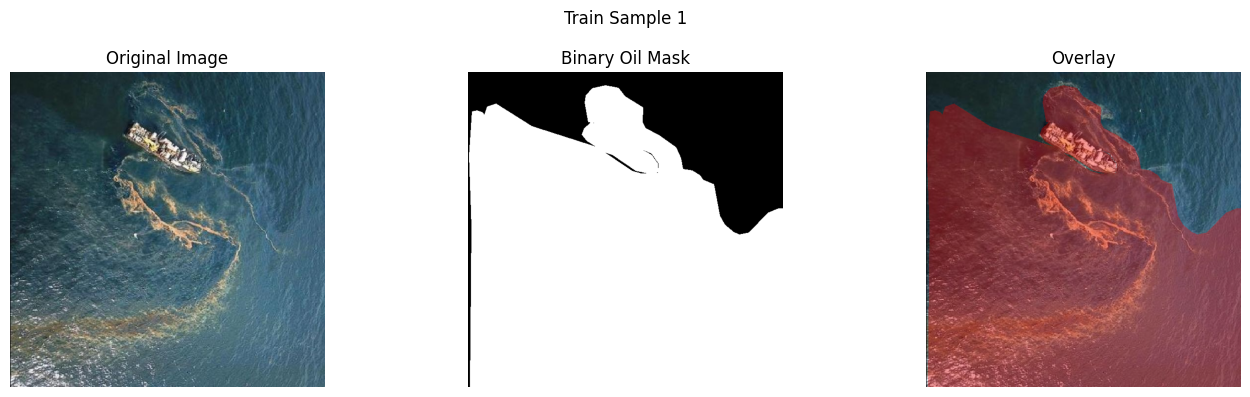

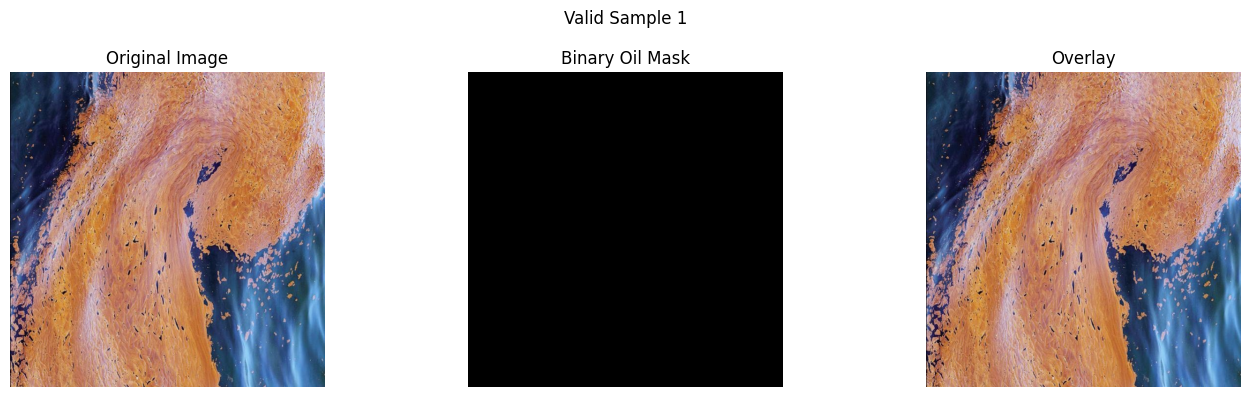

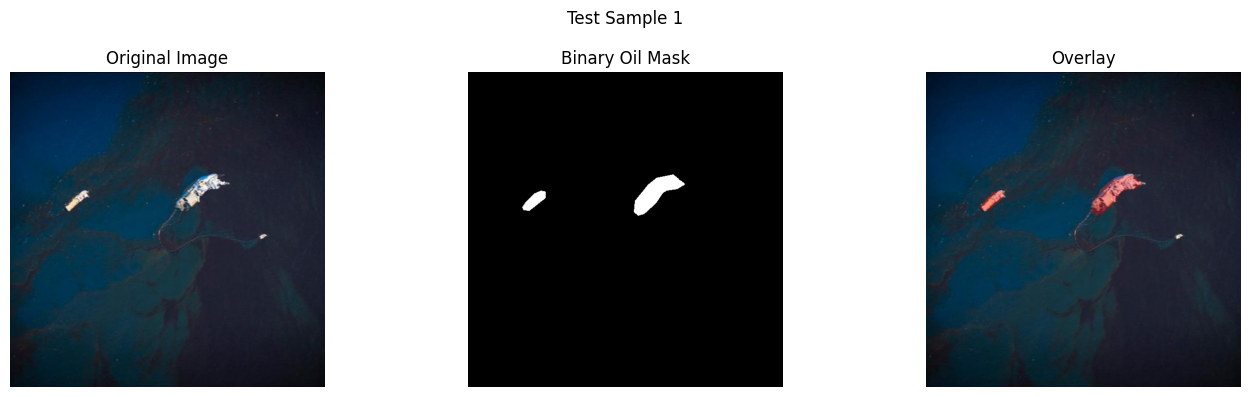

In [7]:
# ============================================================
# Step 4: Visualize Image, Binary Mask, and Overlay
# ============================================================

def show_sample(image_path, mask_path, title="Sample"):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_bin = (mask > 127).astype(np.uint8)

    overlay = img.copy()
    overlay[mask_bin == 1] = [255, 0, 0]

    blended = cv2.addWeighted(img, 0.65, overlay, 0.35, 0)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_bin, cmap="gray")
    plt.title("Binary Oil Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(blended)
    plt.title("Overlay")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_sample(train_image_paths[0], train_mask_paths[0], title="Train Sample 1")
show_sample(valid_image_paths[0], valid_mask_paths[0], title="Valid Sample 1")
show_sample(test_image_paths[0], test_mask_paths[0], title="Test Sample 1")

In [8]:
# ============================================================
# Step 4B: Check empty masks in processed dataset
# ============================================================

def check_empty_masks(mask_paths, split_name):
    empty_count = 0
    non_empty_count = 0
    oil_pixel_counts = []

    for mask_path in mask_paths:
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print("Failed to read:", mask_path)
            continue

        mask_bin = (mask > 127).astype(np.uint8)
        oil_pixels = int(mask_bin.sum())
        oil_pixel_counts.append(oil_pixels)

        if oil_pixels == 0:
            empty_count += 1
        else:
            non_empty_count += 1

    total = len(mask_paths)
    empty_ratio = empty_count / total if total > 0 else 0

    print(f"\n{split_name} split")
    print("Total masks:", total)
    print("Empty masks:", empty_count)
    print("Non-empty masks:", non_empty_count)
    print("Empty mask ratio:", round(empty_ratio, 4))
    print("Min oil pixels:", min(oil_pixel_counts) if oil_pixel_counts else None)
    print("Max oil pixels:", max(oil_pixel_counts) if oil_pixel_counts else None)

    return {
        "split": split_name,
        "total": total,
        "empty_masks": empty_count,
        "non_empty_masks": non_empty_count,
        "empty_ratio": empty_ratio
    }


empty_summary = []

empty_summary.append(check_empty_masks(train_mask_paths, "Train"))
empty_summary.append(check_empty_masks(valid_mask_paths, "Valid"))
empty_summary.append(check_empty_masks(test_mask_paths, "Test"))

empty_summary_df = pd.DataFrame(empty_summary)
empty_summary_df


Train split
Total masks: 2223
Empty masks: 892
Non-empty masks: 1331
Empty mask ratio: 0.4013
Min oil pixels: 0
Max oil pixels: 409600

Valid split
Total masks: 675
Empty masks: 281
Non-empty masks: 394
Empty mask ratio: 0.4163
Min oil pixels: 0
Max oil pixels: 409600

Test split
Total masks: 343
Empty masks: 134
Non-empty masks: 209
Empty mask ratio: 0.3907
Min oil pixels: 0
Max oil pixels: 409600


,split,total,empty_masks,non_empty_masks,empty_ratio
0,Train,2223,892,1331,0.401260
1,Valid,675,281,394,0.416296
2,Test,343,134,209,0.390671


In [9]:
# ============================================================
# Step 5: Data Pipeline for Optimized Edge U-Net
# ============================================================

def read_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)

    # Required for MobileNetV2 pretrained encoder
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image


def read_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)

    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")
    mask = tf.cast(mask > 127, tf.float32)

    return mask


def augment_pair(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    image = tf.image.random_brightness(image, max_delta=0.10)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)

    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise

    image = tf.clip_by_value(image, -1.0, 1.0)

    return image, mask


def load_pair(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)
    return image, mask


def make_dataset(image_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(
            buffer_size=min(len(image_paths), 512),
            seed=SEED,
            reshuffle_each_iteration=True
        )
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_image_paths, train_mask_paths, training=True)
valid_ds = make_dataset(valid_image_paths, valid_mask_paths, training=False)
test_ds = make_dataset(test_image_paths, test_mask_paths, training=False)

for images, masks in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Mask batch:", masks.shape)
    print("Image min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))
    print("Mask min/max:", float(tf.reduce_min(masks)), float(tf.reduce_max(masks)))

Image batch: (8, 192, 192, 3)
Mask batch: (8, 192, 192, 1)
Image min/max: -1.0 1.0
Mask min/max: 0.0 1.0


In [10]:
# ============================================================
# Step 6: Metrics and Focal Dice Loss
# ============================================================

SMOOTH = 1e-6

def dice_coef(y_true, y_pred, smooth=SMOOTH):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


bce_focal = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

def focal_dice_loss(y_true, y_pred):
    focal = bce_focal(y_true, y_pred)
    dloss = dice_loss(y_true, y_pred)
    return 0.4 * focal + 0.6 * dloss

In [12]:
# ============================================================
# Step 7: Build Optimized Edge U-Net Model
# ============================================================

def sep_conv_block(x, filters, dropout=0.0, name=None):
    x = tf.keras.layers.SeparableConv2D(
        filters, 3, padding="same", use_bias=False,
        name=None if name is None else f"{name}_sepconv1"
    )(x)
    x = tf.keras.layers.BatchNormalization(
        name=None if name is None else f"{name}_bn1"
    )(x)
    x = tf.keras.layers.ReLU(
        name=None if name is None else f"{name}_relu1"
    )(x)

    x = tf.keras.layers.SeparableConv2D(
        filters, 3, padding="same", use_bias=False,
        name=None if name is None else f"{name}_sepconv2"
    )(x)
    x = tf.keras.layers.BatchNormalization(
        name=None if name is None else f"{name}_bn2"
    )(x)
    x = tf.keras.layers.ReLU(
        name=None if name is None else f"{name}_relu2"
    )(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout)(x)

    return x


def build_edge_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=MOBILENET_ALPHA):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        alpha=alpha
    )

    skip_names = [
        "block_1_expand_relu",
        "block_3_expand_relu",
        "block_6_expand_relu",
        "block_13_expand_relu",
        "block_16_project",
    ]

    skip_outputs = [base.get_layer(name).output for name in skip_names]
    encoder = tf.keras.Model(base.input, skip_outputs, name="mobilenetv2_encoder")
    encoder.trainable = False

    inputs = tf.keras.Input(shape=input_shape, name="input_image")

    s1, s2, s3, s4, bottleneck = encoder(inputs, training=False)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(bottleneck)
    x = tf.keras.layers.Concatenate()([x, s4])
    x = sep_conv_block(x, 128, dropout=0.08, name="decoder_12")

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, s3])
    x = sep_conv_block(x, 96, dropout=0.08, name="decoder_24")

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, s2])
    x = sep_conv_block(x, 64, dropout=0.05, name="decoder_48")

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, s1])
    x = sep_conv_block(x, 32, dropout=0.03, name="decoder_96")

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = sep_conv_block(x, 16, dropout=0.02, name="decoder_192")

    outputs = tf.keras.layers.Conv2D(
        1, 1, activation="sigmoid", padding="same", name="oil_mask"
    )(x)

    model = tf.keras.Model(inputs, outputs, name="Edge_UNet_Lite_Improved")
    return model


model = build_edge_unet()
model.summary()
print("Total parameters:", model.count_params())

5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Edge_UNet_Lite_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 96, 96,   │  1,068,784 │ input_image[0][0] │
│ (Functional)        │ 96), (None, 48,   │            │                   │
│                     │ 48, 144), (None,  │            │                   │
│                     │ 24, 24, 144),     │            │                   │
│                     │ (None, 12, 12,    │            │                   │
│                     │ 432), (None, 6,   │            │                   │
│                     │ 6, 240)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 12, 12,    │          0 │ mobilenetv2_enco… │
│ (UpSampling2D)      │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12, 12,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 672)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_12_sepconv1 │ (None, 12, 12,    │     92,064 │ concatenate[0][0] │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_12_bn1      │ (None, 12, 12,    │        512 │ decoder_12_sepco… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_12_relu1    │ (None, 12, 12,    │          0 │ decoder_12_bn1[0… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_12_sepconv2 │ (None, 12, 12,    │     17,536 │ decoder_12_relu1… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_12_bn2      │ (None, 12, 12,    │        512 │ decoder_12_sepco… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_12_relu2    │ (None, 12, 12,    │          0 │ decoder_12_bn2[0… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 12,    │          0 │ decoder_12_relu2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 24, 24,    │          0 │ dropout[0][0]     │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 24, 24,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 272)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_24_sepconv1 │ (None, 24, 24,    │     28,560 │ concatenate_1[0]… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_24_bn1      │ (None, 24, 24,    │        384 │ decoder_24_sepco… │
│ (BatchNormalizatio… │ 96)               │            │                 

 Total params: 1,250,993 (4.77 MB)

 Trainable params: 180,865 (706.50 KB)

 Non-trainable params: 1,070,128 (4.08 MB)

Total parameters: 1250993


In [13]:
# ============================================================
# Step 8: Compile Model and Training Callbacks
# ============================================================

def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_dice_loss,
        metrics=[
            dice_coef,
            tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
        ],
    )


def build_callbacks(save_path, log_path, monitor="val_dice_coef"):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(save_path),
            monitor=monitor,
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(log_path))
    ]

In [14]:
# ============================================================
# Step 9: Stage 1 Training - Frozen Encoder
# ============================================================

stage1_path = MODEL_DIR / "edge_unet_stage1_best.keras"
stage1_log_path = LOG_DIR / "edge_unet_stage1_training_log.csv"

compile_model(model, INITIAL_LR)

history_stage1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=build_callbacks(stage1_path, stage1_log_path),
)

print("Stage 1 best model saved:", stage1_path)

Epoch 1/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.4674 - dice_coef: 0.3922 - iou: 0.2836 - loss: 0.5090 - precision: 0.3073 - recall: 0.7873
Epoch 1: val_dice_coef improved from None to 0.27407, saving model to /content/drive/MyDrive/Oil Spill/Best Detection Model/models/edge_unet_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil Spill/Best Detection Model/models/edge_unet_stage1_best.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 167s 375ms/step - accuracy: 0.5507 - dice_coef: 0.3654 - iou: 0.2839 - loss: 0.5018 - precision: 0.3098 - recall: 0.7727 - val_accuracy: 0.6313 - val_dice_coef: 0.2741 - val_iou: 0.1956 - val_loss: 0.5036 - val_precision: 0.2851 - val_recall: 0.3837 - learning_rate: 1.0000e-04
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7397 - dice_coef: 0.4343 - iou: 0.4028 - loss: 0.4134 - precision: 0.5038 - recall: 0.6681
Epoch 2: val_dice_coef improved from 0.27407 to 0.29389, saving model to /content/drive/MyDri

In [15]:
# ============================================================
# Step 10: Stage 2 Fine-Tuning
# ============================================================

def unfreeze_last_encoder_layers(model, n_last_layers=30):
    encoder = model.get_layer("mobilenetv2_encoder")
    encoder.trainable = True

    for layer in encoder.layers[:-n_last_layers]:
        layer.trainable = False

    for layer in encoder.layers[-n_last_layers:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    trainable_layers = [layer.name for layer in encoder.layers if layer.trainable]

    print("Trainable encoder layers:", len(trainable_layers))
    print("Last trainable layers:", trainable_layers[-10:])


model = tf.keras.models.load_model(
    stage1_path,
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

unfreeze_last_encoder_layers(model, n_last_layers=30)
compile_model(model, FINE_TUNE_LR)

stage2_path = MODEL_DIR / "edge_unet_stage2_best.keras"
stage2_log_path = LOG_DIR / "edge_unet_stage2_training_log.csv"

history_stage2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_2,
    callbacks=build_callbacks(stage2_path, stage2_log_path),
)

print("Stage 2 best model saved:", stage2_path)

Trainable encoder layers: 20
Last trainable layers: ['block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project']
Epoch 1/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8864 - dice_coef: 0.6930 - iou: 0.6414 - loss: 0.2500 - precision: 0.8121 - recall: 0.7546
Epoch 1: val_dice_coef improved from None to 0.55419, saving model to /content/drive/MyDrive/Oil Spill/Best Detection Model/models/edge_unet_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil Spill/Best Detection Model/models/edge_unet_stage2_best.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 114s 253ms/step - accuracy: 0.8938 - dice_coef: 0.6539 - iou: 0.6282 - loss: 0.2655 - precision: 0.7650 - recall: 0.7784 - val_accuracy: 0.9001 - val_dice_coef: 0.5542 - val_iou: 0.6684 - val_loss: 0.3184 - val_precision: 0.7483 - val_recall: 0.8623 - lea

In [17]:
# ============================================================
# Step 11: Save Final Best Edge U-Net Model
# ============================================================

BEST_MODEL_PATH = MODEL_DIR / "best_edge_unet_model.keras"

best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

best_model.save(BEST_MODEL_PATH)

print("Final best Edge U-Net model saved:", BEST_MODEL_PATH)

Final best Edge U-Net model saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/models/best_edge_unet_model.keras


In [19]:
# ============================================================
# Step 11: Save Final Best Edge U-Net Model
# ============================================================

BEST_MODEL_PATH = MODEL_DIR / "best_edge_unet_model.keras"

best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

best_model.save(BEST_MODEL_PATH)

print("Final best Edge U-Net model saved:", BEST_MODEL_PATH)

Final best Edge U-Net model saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/models/best_edge_unet_model.keras


Combined training log saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/logs/edge_unet_combined_training_log.csv


/tmp/ipykernel_592/3554644680.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([stage1_df, stage2_df], ignore_index=True)


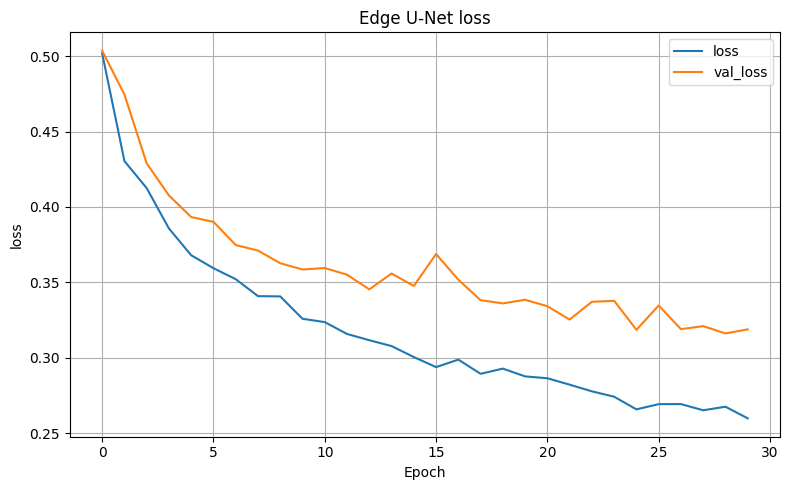

Saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/plots/edge_unet_loss_curve.png


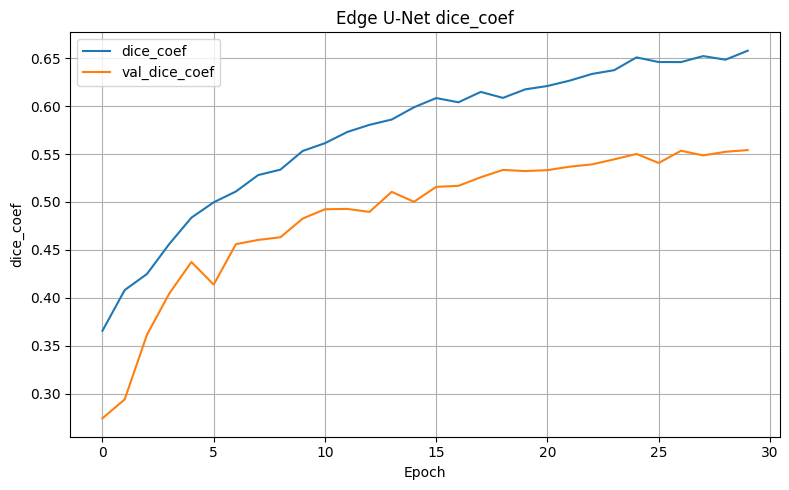

Saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/plots/edge_unet_dice_curve.png


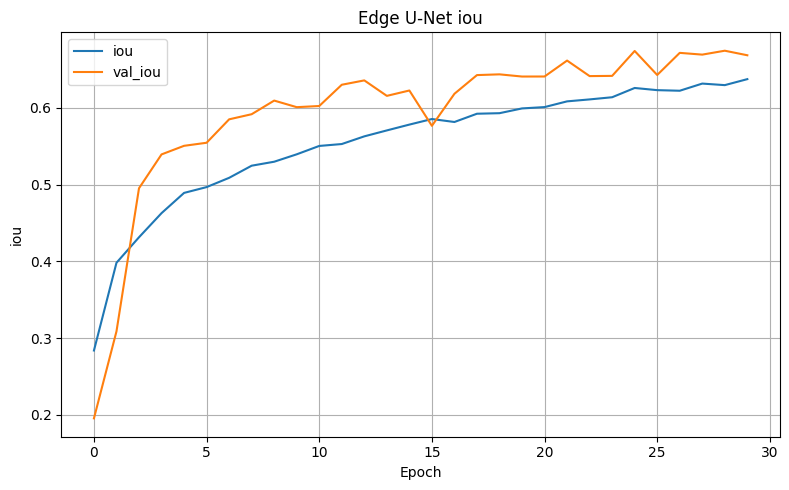

Saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/plots/edge_unet_iou_curve.png


In [22]:
# ============================================================
# Step 12: Save Combined Training Logs and Curves
# ============================================================

stage1_df = pd.read_csv(stage1_log_path)
stage1_df["stage"] = "stage_1_frozen_encoder"

try:
    stage2_df = pd.read_csv(stage2_log_path)
    stage2_df["stage"] = "stage_2_fine_tuning"
except pd.errors.EmptyDataError:
    print(f"Warning: {stage2_log_path} is empty or malformed. Creating an empty DataFrame for stage 2 logs.")
    stage2_df = pd.DataFrame(columns=stage1_df.columns) # Ensure columns match for potential future non-empty data
except FileNotFoundError:
    print(f"Warning: {stage2_log_path} not found. Creating an empty DataFrame for stage 2 logs.")
    stage2_df = pd.DataFrame(columns=stage1_df.columns)

# Filter out empty dataframes before concatenation to prevent FutureWarning
dataframes_to_concat = [stage1_df]
if not stage2_df.empty:
    dataframes_to_concat.append(stage2_df)

combined_df = pd.concat(dataframes_to_concat, ignore_index=True)

combined_log_path = LOG_DIR / "edge_unet_combined_training_log.csv"
combined_df.to_csv(combined_log_path, index=False)

print("Combined training log saved:", combined_log_path)


def plot_curve(df, metric, save_name):
    plt.figure(figsize=(8, 5))
    plt.plot(df[metric], label=metric)

    val_metric = "val_" + metric
    if val_metric in df.columns:
        plt.plot(df[val_metric], label=val_metric)

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Edge U-Net {metric}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    save_path = PLOT_DIR / save_name
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved:", save_path)


plot_curve(combined_df, "loss", "edge_unet_loss_curve.png")
plot_curve(combined_df, "dice_coef", "edge_unet_dice_curve.png")
plot_curve(combined_df, "iou", "edge_unet_iou_curve.png")

In [23]:
# ============================================================
# Step 13: Evaluate Best Model at Default Threshold 0.5
# ============================================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

results = best_model.evaluate(test_ds, verbose=1)
metrics = dict(zip(best_model.metrics_names, results))

print("=== Edge U-Net Test Metrics at Threshold 0.5 ===")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

with open(RESULT_DIR / "edge_unet_test_metrics_threshold_0_5.json", "w") as f:
    json.dump(metrics, f, indent=2)

43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 269ms/step - accuracy: 0.8950 - dice_coef: 0.5962 - iou: 0.6779 - loss: 0.3074 - precision: 0.7590 - recall: 0.8638
=== Edge U-Net Test Metrics at Threshold 0.5 ===
loss: 0.307412
compile_metrics: 0.596223


Best threshold: 0.6200000000000003
tn             8.725263e+06
fp             6.839640e+05
fn             5.554130e+05
tp             2.679712e+06
accuracy       9.019818e-01
precision      7.966617e-01
recall         8.283179e-01
specificity    9.273092e-01
iou            6.837589e-01
dice           8.121815e-01
threshold      6.200000e-01
Name: 16, dtype: float64


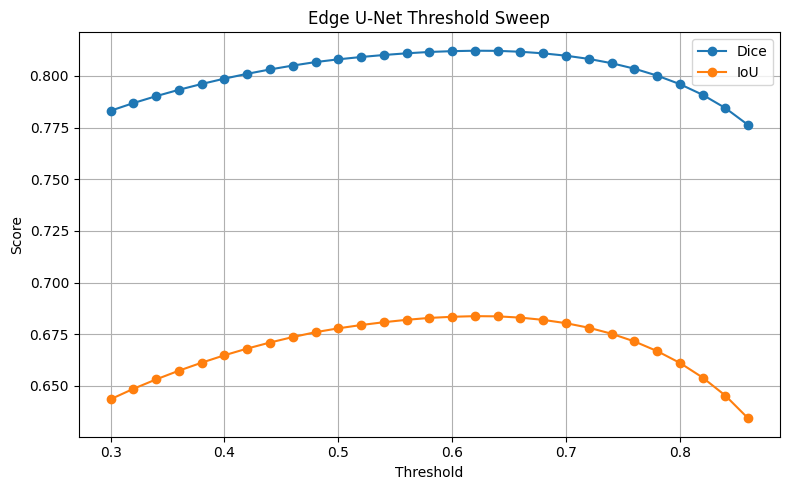

In [24]:
# ============================================================
# Step 14: Threshold Tuning
# ============================================================

def gather_predictions(model, dataset):
    all_true = []
    all_prob = []

    for images, masks in dataset:
        preds = model.predict(images, verbose=0)

        all_true.append(masks.numpy().astype(np.uint8).flatten())
        all_prob.append(preds.flatten())

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)

    return y_true, y_prob


def compute_metrics_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    def safe_div(a, b):
        return float(a / b) if b else 0.0

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": safe_div(tp + tn, total),
        "precision": safe_div(tp, tp + fp),
        "recall": safe_div(tp, tp + fn),
        "specificity": safe_div(tn, tn + fp),
        "iou": safe_div(tp, tp + fp + fn),
        "dice": safe_div(2 * tp, 2 * tp + fp + fn),
    }


y_true, y_prob = gather_predictions(best_model, test_ds)

thresholds = np.arange(0.30, 0.86, 0.02)
threshold_results = []

for th in thresholds:
    y_pred = (y_prob > th).astype(np.uint8)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    row = compute_metrics_from_cm(cm)
    row["threshold"] = float(th)
    threshold_results.append(row)

threshold_df = pd.DataFrame(threshold_results)
threshold_df.to_csv(RESULT_DIR / "edge_unet_threshold_sweep_results.csv", index=False)

best_row = threshold_df.loc[threshold_df["dice"].idxmax()]
best_threshold = float(best_row["threshold"])

print("Best threshold:", best_threshold)
print(best_row)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["dice"], label="Dice", marker="o")
plt.plot(threshold_df["threshold"], threshold_df["iou"], label="IoU", marker="o")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Edge U-Net Threshold Sweep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "edge_unet_threshold_sweep.png", dpi=200)
plt.show()

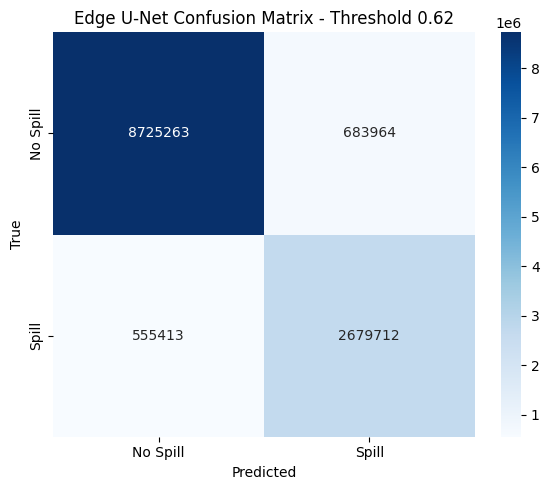

In [26]:
# ============================================================
# Step 15: Confusion Matrix at Best Threshold
# ============================================================

best_pred = (y_prob > best_threshold).astype(np.uint8)
cm = confusion_matrix(y_true, best_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["True No Spill", "True Spill"],
    columns=["Pred No Spill", "Pred Spill"]
)
cm_df.to_csv(RESULT_DIR / "edge_unet_confusion_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Spill", "Spill"],
    yticklabels=["No Spill", "Spill"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Edge U-Net Confusion Matrix - Threshold {best_threshold:.2f}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "edge_unet_confusion_matrix.png", dpi=200)
plt.show()

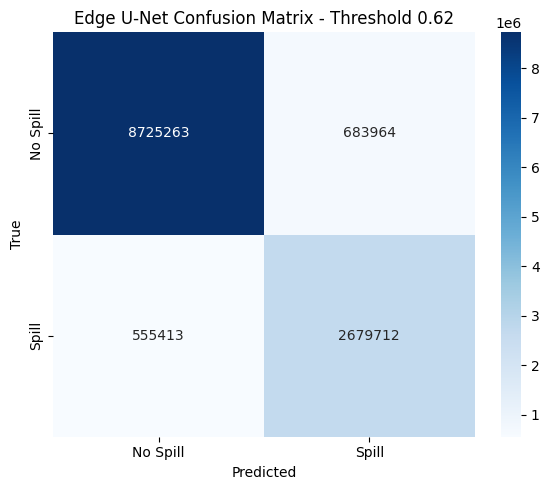

In [27]:
# ============================================================
# Step 15: Confusion Matrix at Best Threshold
# ============================================================

best_pred = (y_prob > best_threshold).astype(np.uint8)
cm = confusion_matrix(y_true, best_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["True No Spill", "True Spill"],
    columns=["Pred No Spill", "Pred Spill"]
)
cm_df.to_csv(RESULT_DIR / "edge_unet_confusion_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Spill", "Spill"],
    yticklabels=["No Spill", "Spill"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Edge U-Net Confusion Matrix - Threshold {best_threshold:.2f}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "edge_unet_confusion_matrix.png", dpi=200)
plt.show()

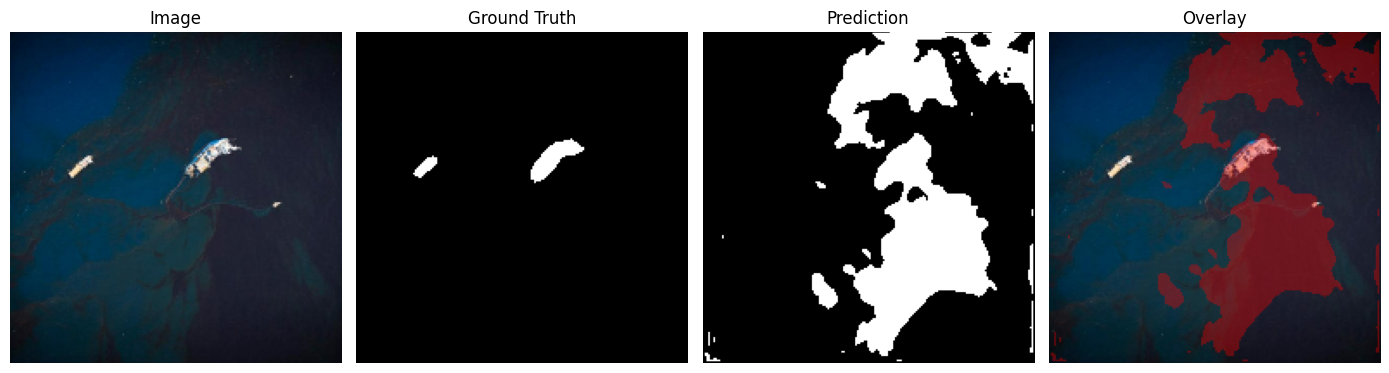

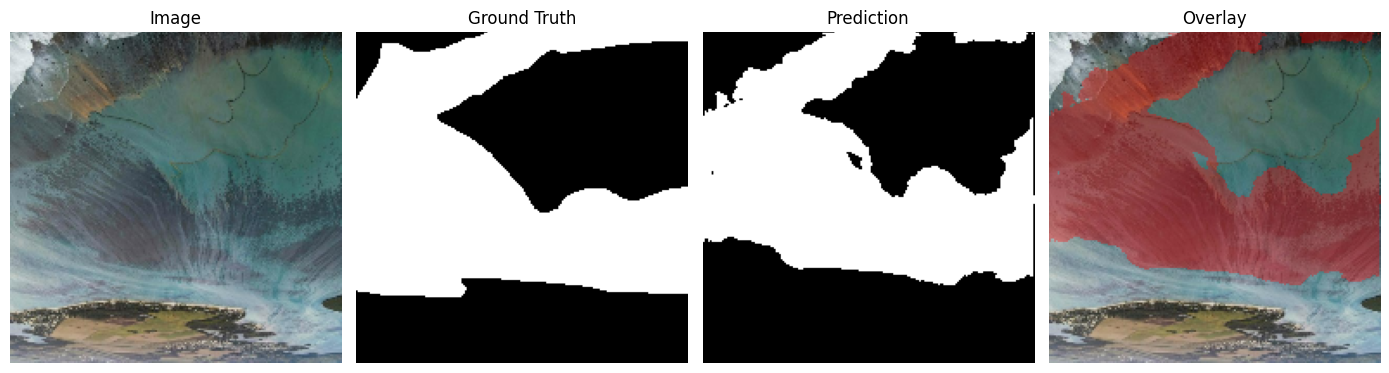

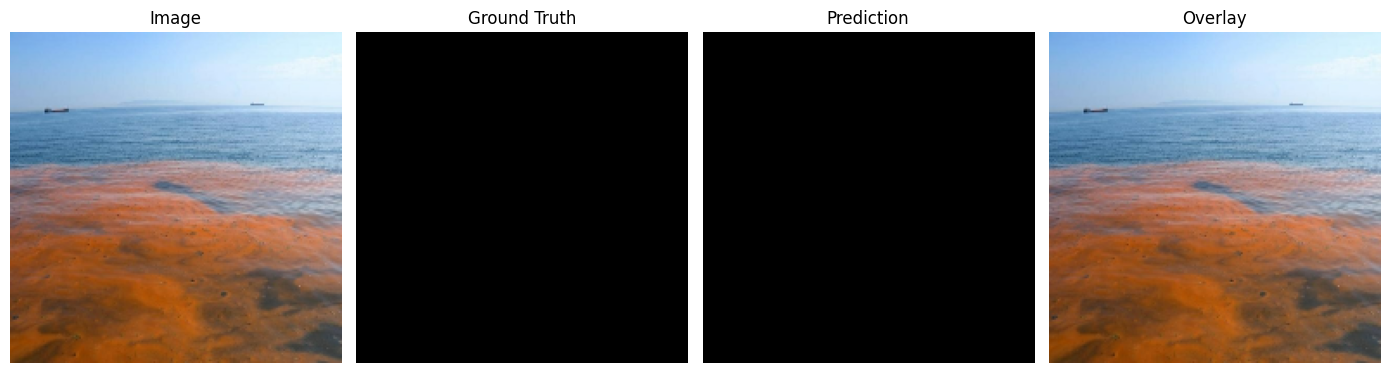

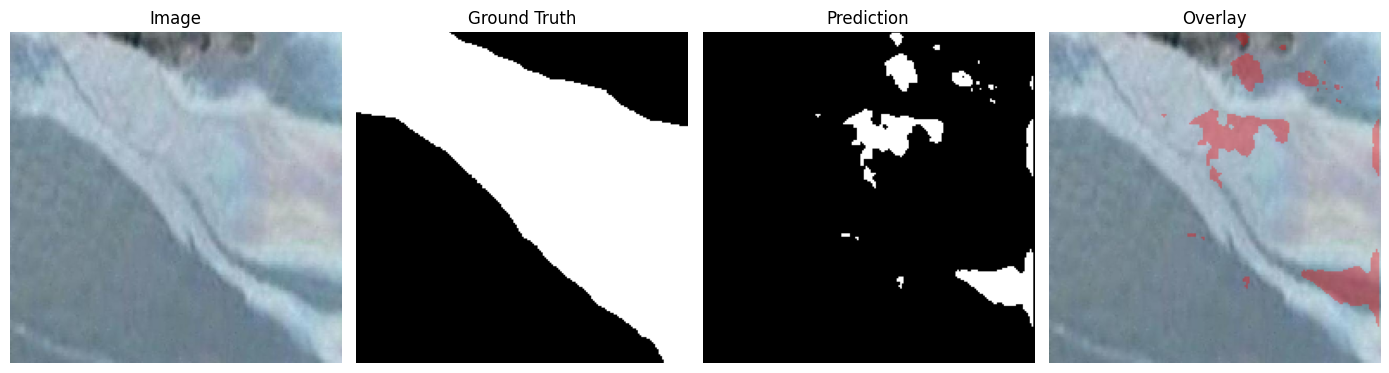

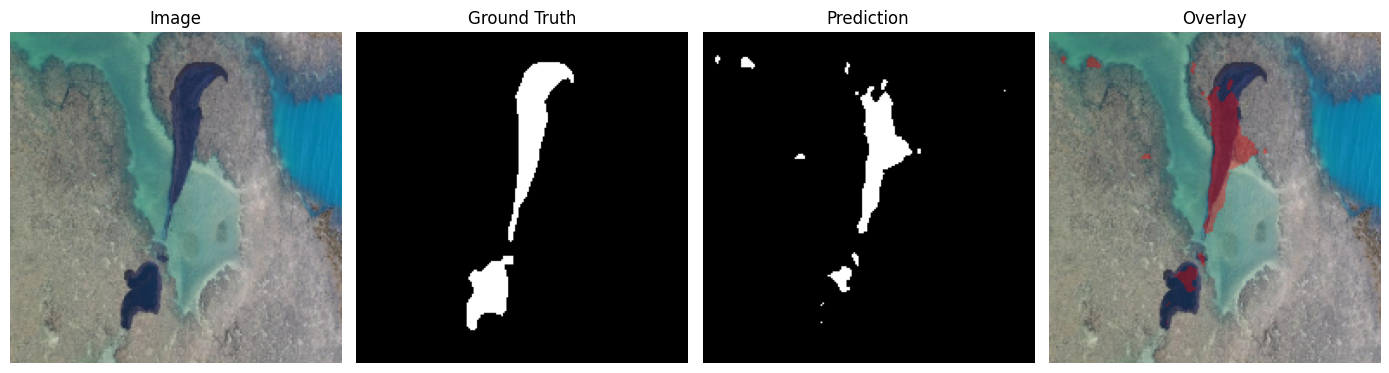

Saved sample predictions to: /content/drive/MyDrive/Oil Spill/Best Detection Model/plots/edge_unet_sample_predictions


In [28]:
# ============================================================
# Step 16: Save Qualitative Predictions
# ============================================================

qual_dir = PLOT_DIR / "edge_unet_sample_predictions"
qual_dir.mkdir(parents=True, exist_ok=True)

for images, masks in test_ds.take(1):
    preds = best_model.predict(images, verbose=0)
    preds_bin = (preds > best_threshold).astype(np.float32)

    for i in range(min(5, images.shape[0])):
        img = (images[i].numpy() + 1.0) / 2.0
        img = np.clip(img, 0, 1)

        true_mask = masks[i].numpy().squeeze()
        pred_mask = preds_bin[i].squeeze()

        overlay = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended = 0.65 * img + 0.35 * overlay

        plt.figure(figsize=(14, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(blended)
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        save_path = qual_dir / f"edge_unet_prediction_{i+1}.png"
        plt.savefig(save_path, dpi=200)
        plt.show()

print("Saved sample predictions to:", qual_dir)

In [29]:
# ============================================================
# Step 17: Save Final Edge U-Net Summary
# ============================================================

best_metrics = best_row.to_dict()

summary = {
    "experiment_id": EXPERIMENT_ID,
    "model_name": "Edge_UNet_Lite_Improved",
    "encoder": "MobileNetV2",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "mobilenet_alpha": MOBILENET_ALPHA,
    "stage_1_epochs": EPOCHS_STAGE_1,
    "stage_2_epochs": EPOCHS_STAGE_2,
    "initial_lr": INITIAL_LR,
    "fine_tune_lr": FINE_TUNE_LR,
    "loss": "Focal Dice Loss",
    "best_threshold": best_threshold,
    "metrics": best_metrics,
    "model_path": str(BEST_MODEL_PATH),
}

summary_path = RESULT_DIR / "edge_unet_final_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

summary_md = f"""
# Edge U-Net Improved Detection Summary

## Experiment
- Experiment ID: {EXPERIMENT_ID}
- Model: Edge_UNet_Lite_Improved
- Encoder: MobileNetV2
- MobileNet alpha: {MOBILENET_ALPHA}
- Image size: {IMG_SIZE} x {IMG_SIZE}
- Batch size: {BATCH_SIZE}
- Stage 1 epochs: {EPOCHS_STAGE_1}
- Stage 2 epochs: {EPOCHS_STAGE_2}
- Loss: Focal Dice Loss
- Best threshold: {best_threshold:.2f}

## Final Improved Model Metrics
- Accuracy: {best_metrics['accuracy']:.4f}
- Precision: {best_metrics['precision']:.4f}
- Recall: {best_metrics['recall']:.4f}
- Specificity: {best_metrics['specificity']:.4f}
- IoU: {best_metrics['iou']:.4f}
- Dice: {best_metrics['dice']:.4f}

## Confusion Counts
- TN: {int(best_metrics['tn'])}
- FP: {int(best_metrics['fp'])}
- FN: {int(best_metrics['fn'])}
- TP: {int(best_metrics['tp'])}

## Model File
- {BEST_MODEL_PATH}

## Purpose
This model is the optimized best Edge U-Net detection model. It uses a lightweight MobileNetV2 encoder, separable convolution decoder, Focal Dice Loss, two-stage training, and threshold tuning for oil-spill segmentation.
"""

summary_md_path = RESULT_DIR / "EDGE_UNET_OUTPUT_SUMMARY.md"
summary_md_path.write_text(summary_md)

print(summary_md)
print("Saved:", summary_path)
print("Saved:", summary_md_path)


# Edge U-Net Improved Detection Summary

## Experiment
- Experiment ID: E02_BEST_EDGE_UNET_MOBILENETV2_192_FOCAL_DICE
- Model: Edge_UNet_Lite_Improved
- Encoder: MobileNetV2
- MobileNet alpha: 0.75
- Image size: 192 x 192
- Batch size: 8
- Stage 1 epochs: 30
- Stage 2 epochs: 20
- Loss: Focal Dice Loss
- Best threshold: 0.62

## Final Improved Model Metrics
- Accuracy: 0.9020
- Precision: 0.7967
- Recall: 0.8283
- Specificity: 0.9273
- IoU: 0.6838
- Dice: 0.8122

## Confusion Counts
- TN: 8725263
- FP: 683964
- FN: 555413
- TP: 2679712

## Model File
- /content/drive/MyDrive/Oil Spill/Best Detection Model/models/best_edge_unet_model.keras

## Purpose
This model is the optimized best Edge U-Net detection model. It uses a lightweight MobileNetV2 encoder, separable convolution decoder, Focal Dice Loss, two-stage training, and threshold tuning for oil-spill segmentation.

Saved: /content/drive/MyDrive/Oil Spill/Best Detection Model/results/edge_unet_final_summary.json
Saved: /content/driv

In [30]:
# ============================================================
# Step 18: TensorFlow Lite FP16 and INT8 Conversion
# ============================================================

TFLITE_DIR = PROJECT_DIR / "tflite"
TFLITE_DIR.mkdir(parents=True, exist_ok=True)

saved_model_dir = TFLITE_DIR / "saved_model_edge_unet"

if saved_model_dir.exists():
    shutil.rmtree(saved_model_dir)

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

if hasattr(best_model, "export"):
    best_model.export(str(saved_model_dir))
else:
    tf.saved_model.save(best_model, str(saved_model_dir))

print("SavedModel exported:", saved_model_dir)


def make_representative_data_gen(train_ds, max_batches=50):
    def representative_data_gen():
        for images, _ in train_ds.take(max_batches):
            images_np = images.numpy()
            for i in range(images_np.shape[0]):
                yield [images_np[i:i+1].astype(np.float32)]
    return representative_data_gen


def file_size_mb(path):
    path = Path(path)
    return path.stat().st_size / (1024 * 1024)


fp16_path = TFLITE_DIR / "edge_unet_fp16.tflite"
int8_path = TFLITE_DIR / "edge_unet_int8.tflite"

# FP16 conversion
converter_fp16 = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter_fp16.convert()

with open(fp16_path, "wb") as f:
    f.write(tflite_fp16)

print("Saved FP16:", fp16_path)
print("FP16 size MB:", file_size_mb(fp16_path))

# INT8 conversion
converter_int8 = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = make_representative_data_gen(train_ds)
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()

with open(int8_path, "wb") as f:
    f.write(tflite_int8)

print("Saved INT8:", int8_path)
print("INT8 size MB:", file_size_mb(int8_path))

size_df = pd.DataFrame([
    {
        "model_format": "Keras",
        "path": str(BEST_MODEL_PATH),
        "size_mb": file_size_mb(BEST_MODEL_PATH)
    },
    {
        "model_format": "TFLite FP16",
        "path": str(fp16_path),
        "size_mb": file_size_mb(fp16_path)
    },
    {
        "model_format": "TFLite INT8",
        "path": str(int8_path),
        "size_mb": file_size_mb(int8_path)
    },
])

size_df.to_csv(RESULT_DIR / "edge_unet_model_size_comparison.csv", index=False)
size_df

Saved artifact at '/content/drive/MyDrive/Oil Spill/Best Detection Model/tflite/saved_model_edge_unet'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 192, 192, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 192, 192, 1), dtype=tf.float32, name=None)
Captures:
  133810682684112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682682960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682683344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682684880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682680656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682679888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682679504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682682192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682680272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810682

,model_format,path,size_mb
0,Keras,/content/drive/MyDrive/Oil Spill/Best Detectio...,12.049788
1,TFLite FP16,/content/drive/MyDrive/Oil Spill/Best Detectio...,2.381962
2,TFLite INT8,/content/drive/MyDrive/Oil Spill/Best Detectio...,1.584251


In [31]:
# ============================================================
# Step 19: Quick TFLite Inference Test
# ============================================================

def quick_tflite_test(model_path, sample_input):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_scale, input_zero_point = input_details[0]["quantization"]
    output_scale, output_zero_point = output_details[0]["quantization"]

    x = sample_input.copy()

    if input_details[0]["dtype"] == np.int8:
        x = np.round(x / input_scale + input_zero_point).astype(np.int8)
    else:
        x = x.astype(input_details[0]["dtype"])

    start = time.time()
    interpreter.set_tensor(input_details[0]["index"], x)
    interpreter.invoke()
    elapsed_ms = (time.time() - start) * 1000

    output = interpreter.get_tensor(output_details[0]["index"])

    if output_details[0]["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero_point) * output_scale

    print("\nModel:", Path(model_path).name)
    print("Inference time:", round(elapsed_ms, 2), "ms")
    print("Output shape:", output.shape)
    print("Output min/max:", float(output.min()), float(output.max()))

    return elapsed_ms


for images, _ in test_ds.take(1):
    sample_input = images[:1].numpy()
    fp16_time = quick_tflite_test(fp16_path, sample_input)
    int8_time = quick_tflite_test(int8_path, sample_input)
    break

latency_df = pd.DataFrame([
    {"model_format": "TFLite FP16", "latency_ms": fp16_time, "size_mb": file_size_mb(fp16_path)},
    {"model_format": "TFLite INT8", "latency_ms": int8_time, "size_mb": file_size_mb(int8_path)},
])

latency_df.to_csv(RESULT_DIR / "edge_unet_tflite_quick_latency.csv", index=False)
latency_df

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Model: edge_unet_fp16.tflite
Inference time: 53.54 ms
Output shape: (1, 192, 192, 1)
Output min/max: 0.005757418926805258 0.9789813160896301

Model: edge_unet_int8.tflite
Inference time: 57.68 ms
Output shape: (1, 192, 192, 1)
Output min/max: 0.00390625 0.94921875


,model_format,latency_ms,size_mb
0,TFLite FP16,53.544521,2.381962
1,TFLite INT8,57.680845,1.584251
